# Implicit Funciton toolboox for geophysics

If we can fit a point data to an Implicit Neural Network, we can operate directly on the Neural Network representation.

Ideas:
loss function z axis by grid levels
taylor expansion continuation

*Paper*
1. Use an INR for implicit gridding and calculate derivatives.
1. Compare against compressed sensing

*TODO*
1. Add val routine
1. Add Comet to run()
1. Consolidate notebooks and git branches
1. Tidy git repo (deprecate old code, clean notebook, validate batched vs non-batched one last time)

*Then:*
1. improve Z axis:
    1. Physics informed loss function?
    1. Predict a small grid and continue it using grid method...
    1. 

*Research questions*
1. Address micro levelling vs tie levelling! understand why microlevelling is required?
1. Block reduction of points
1. Compressed sensing comparison
1. Integrate multiple surveys over same area (careful of environment changes and IRGF!!!)

In [1]:
%load_ext autoreload

%autoreload 2

import random
from pathlib import Path

import comet_ml
import colorcet as cc
import harmonica
import matplotlib.pyplot as plt
import numpy as np
import tifffile
import torch
import xarray as xr
from torch.utils.data import random_split

import geoinr.batcheddatasets
import geoinr.trainval
from geoinr.datasets import NCDataset, CSVDataset, merge_z_slices, construct_xyz, device
from geoinr.models import Siren
from geoinr.models import get_INR as wire
from geoinr.utils import query_inr, query_inr_batched, plt_inr, plt_cntr, plt_3d, plt_sample_locs, plt_kwargs


torch.manual_seed(seed := 0)
random.seed(seed)

In [2]:
# file_path = Path(r"C:\Users\Public\scratch\Ch3\Ice_Cap.csv")
# dataset = geoinr.batcheddatasets.CSVDataset(
#     file_path, variable="MagF", usecols=("X", "Y", "Height_WGS84", "MagF")
# )
# dataset = dataset.subsample_wesnbt((-0.5, 0.6, -0.5, 0.5, -1, 1))
# train_dataset, val_dataset = random_split(dataset, [0.3, 0.7])
# print(f"{len(train_dataset)=}, {len(val_dataset)=}")


In [4]:
netcdf_path = Path(
    "/home/luke/ImplicitGeo/data/Ch3/P864-line-magnetic-AWAGS_MAG_2010.nc"
)
dataset = geoinr.batcheddatasets.NCDataset(netcdf_path, variable="mag_microlevelled")
gtt_path = Path("/home/luke/ImplicitGeo/data/Ch3/P864-grid-tmi.tif")

# netcdf_path = Path(r"C:\Users\Public\scratch\Ch3\P1260\P1260-line-magnetic-AWAGS_MAG_2010.nc")
# dataset.xyz = dataset.xyz[::100]
# dataset.u = dataset.u[::100]
# dataset = dataset.subsample_wesnbt((
#               dataset.normalise(250000, "x"), dataset.normalise(270000, "x"),
#               dataset.normalise(6.755e6, "y"), dataset.normalise(6.765e6, "y"),
#              -1, 1,))

train_dataset, val_dataset = random_split(dataset, [0.8, 0.2])
print(f"{len(train_dataset)=}, {len(val_dataset)=}")
print(f"Dropped {dataset.invalid_points} invalid points")



################
'mag_microlevelled' not found, using 'mag_microLevelled' instead
################

len(train_dataset)=61136, len(val_dataset)=15284
Dropped 0 invalid points


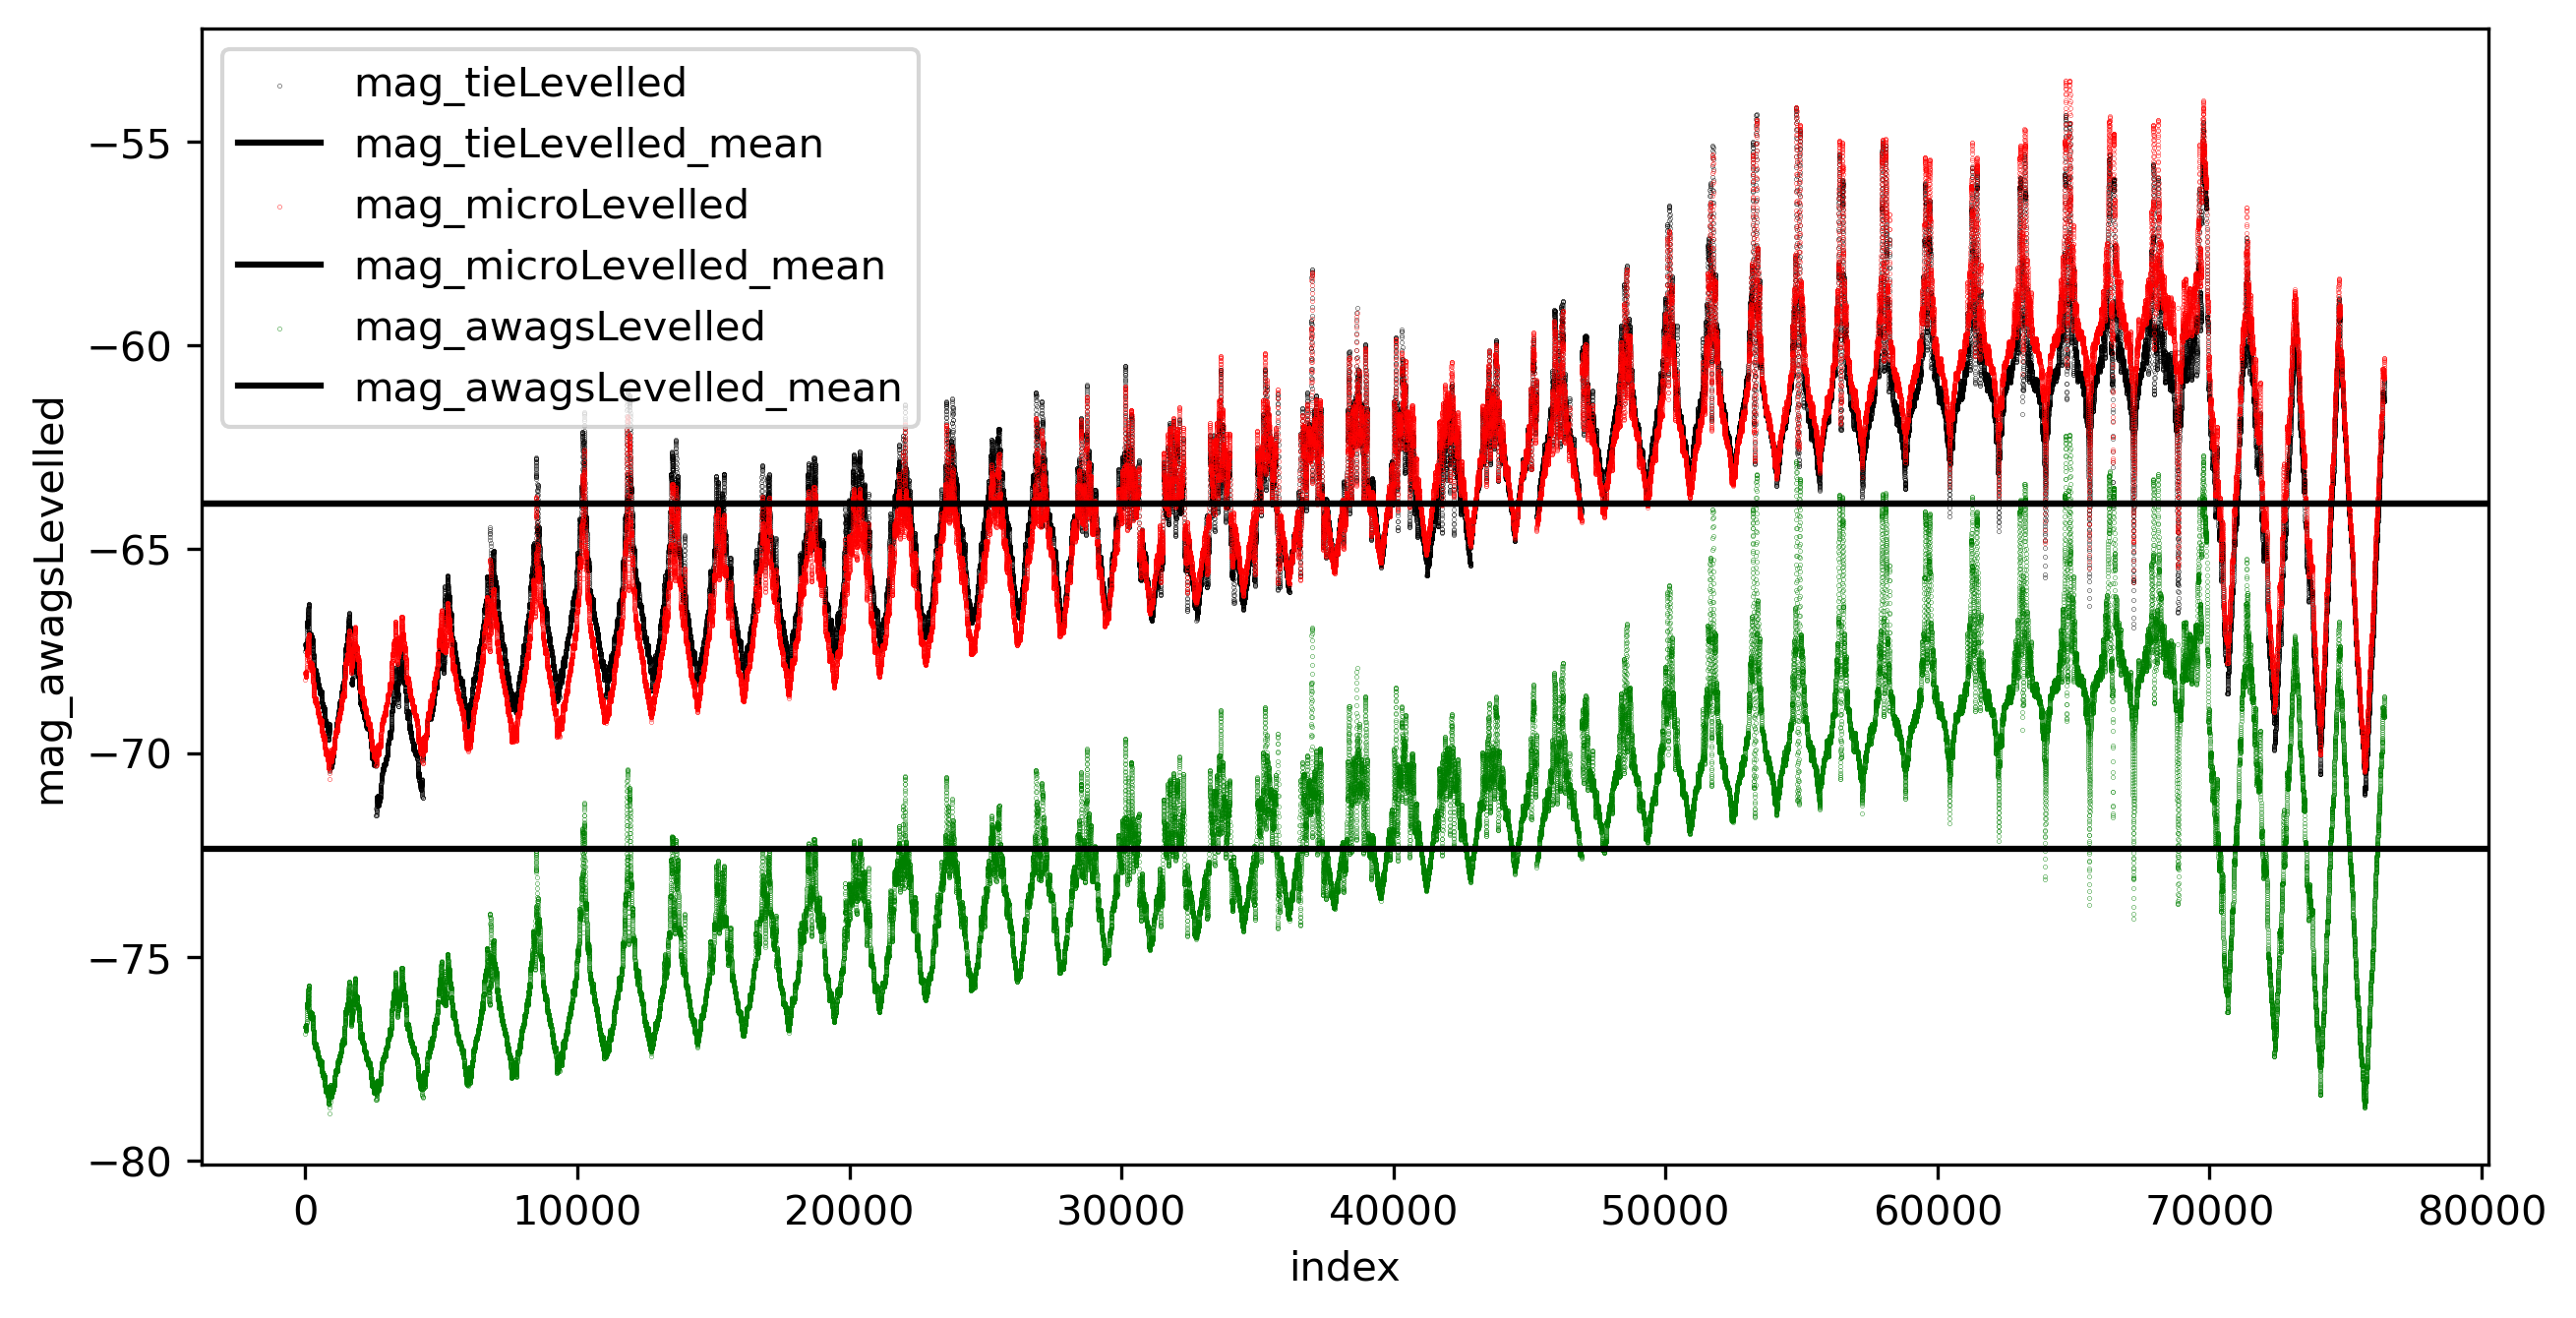

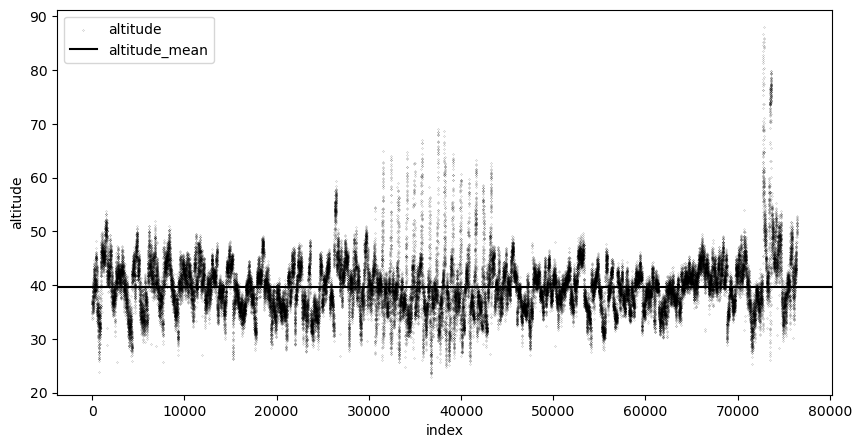

In [25]:
dataset.plot_variables(
    ["mag_tieLevelled", "mag_microLevelled", "mag_awagsLevelled"], s=0.01, dpi=300
)
# "microlevelling removes low amplitude flight line noise after tie line levelling."
dataset.plot_variables(["altitude"], s=0.01, dpi=100)


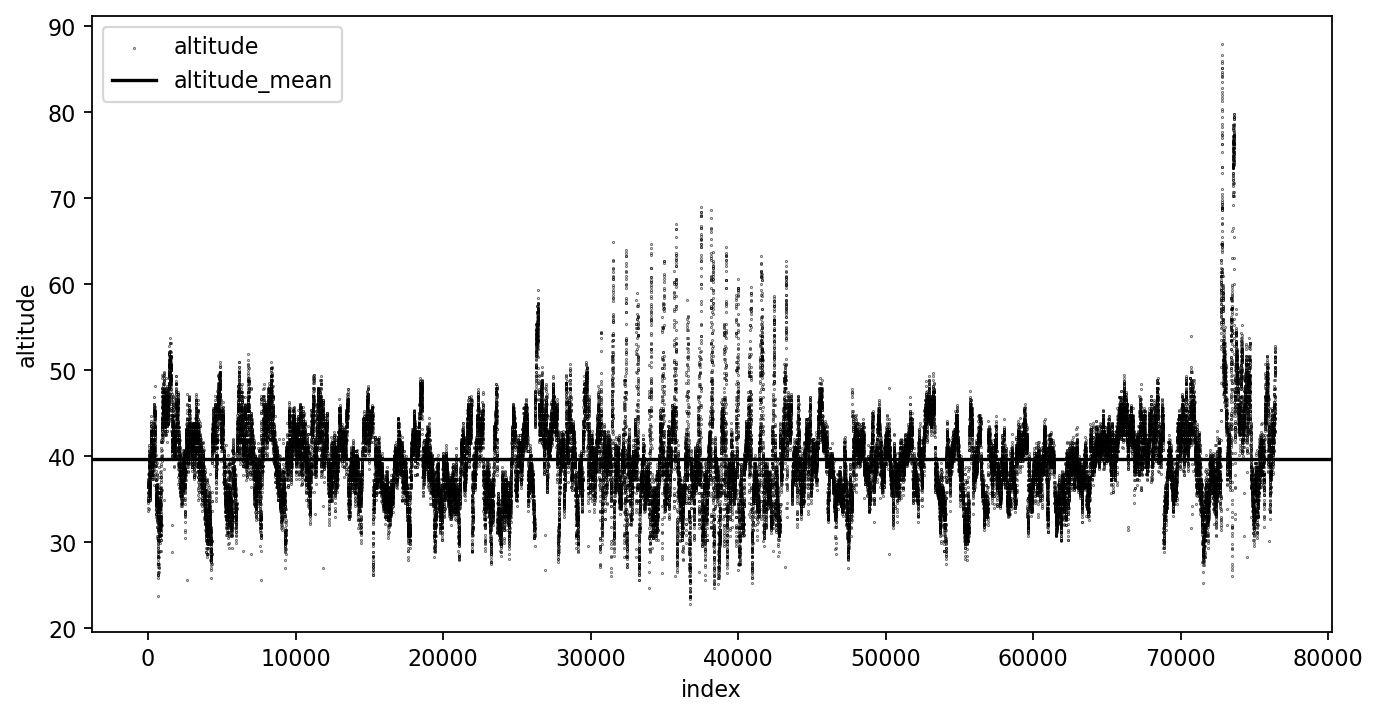

In [6]:
dataset.plot_variables(["altitude"], figsize=(10, 5), dpi=160)


/home/luke/ImplicitGeo/geoinr/utils.py:217: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(x, y, s=1, facecolors=clr, edgecolors=clr, cmap=cc.cm.CET_L1)


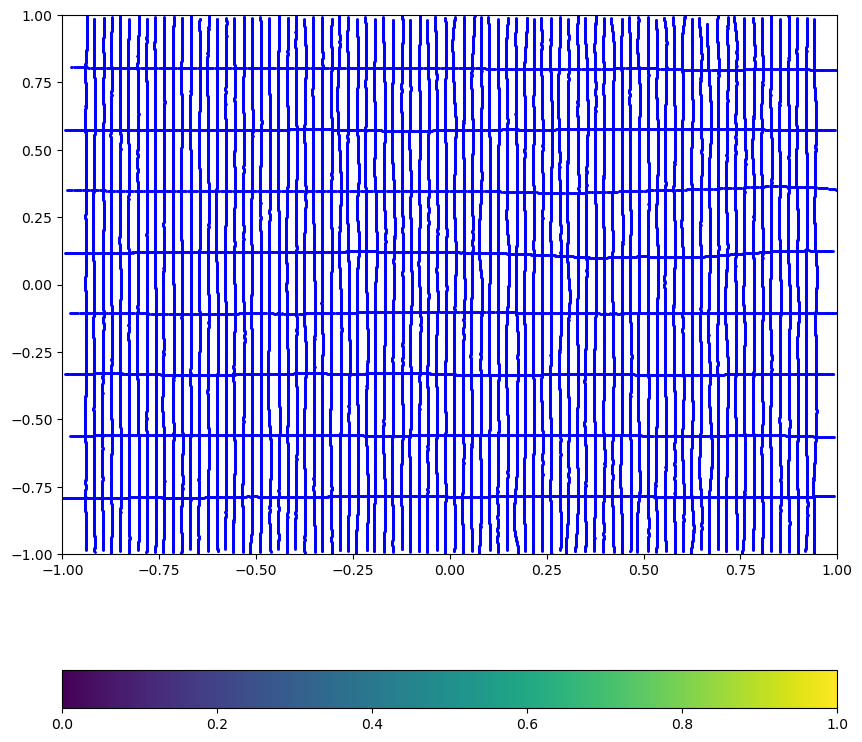

In [7]:
plt_sample_locs(dataset, "b")


In [8]:
# rloss_Sigma = 1e-3 * abs(
#     (1 / (max(dataset.var_ranges["x"]) - min(dataset.var_ranges["x"])))
# )

train_opts = dict(
    total_epochs=1000,  # 00,
    batch_size=1_000_000,  # 2_048_000,  # 1M for 12 GB
    initial_lr=4e-5,
    nonlinearity="sinusoidal",
    hidden_layers=5,
    hidden_features=512,
    weight_rloss=0,  # 1e-3, #1e-4,  # 1e-4,
    rloss_Sigma=2e-6,  # norm width is 2
    n_samples=int(0.1 * dataset.u.shape[0]),  # 10% samples for RLoss
    wire_omega_0=10,
    wire_sigma=10,
    device="cuda",
    use_amp=False,
    # gt_tiff=tifffile.imread(gtt_path),
)

train_dataloader = geoinr.batcheddatasets.BatchingDataloader(
    train_dataset,
    batch_size=train_opts["batch_size"],
    pin_memory=True,
)

val_dataloader = geoinr.batcheddatasets.BatchingDataloader(
    val_dataset,
    batch_size=train_opts["batch_size"],
    pin_memory=True,
)

if train_opts["nonlinearity"] in ["sinusoidal", "siren"]:
    comet_tags = ["SIREN"]
    model = Siren(
        in_features=3,
        out_features=1,
        hidden_features=train_opts["hidden_features"],
        hidden_layers=train_opts["hidden_layers"],
        outermost_linear=True,
    )

elif "wire" in train_opts["nonlinearity"]:
    comet_tags = ["WIRE"]
    model = wire(
        nonlin=train_opts["nonlinearity"],  # "wire2d" | "wire3d"
        in_features=3,
        out_features=1,
        hidden_features=train_opts["hidden_features"],
        hidden_layers=train_opts["hidden_layers"],
        first_omega_0=train_opts["wire_omega_0"],  # first Frequency of sinusoid
        hidden_omega_0=train_opts["wire_omega_0"],  # hidden Frequency of sinusoid
        scale=train_opts["wire_sigma"],  # Sigma of Guassian
    )

f = model.to(device, non_blocking=True)

exp = geoinr.trainval.Exp(
    f,
    {"train": train_dataloader, "val": val_dataloader},
    train_opts,
)
inr = exp.train_inr()


COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/lukesmithgeo/geoinr/c67cf9062c4a437298a9ad25e22b1baa



Training:   0%|          | 0/2000 [00:00<?, ?epoch/s]

COMET INFO: Please wait for metadata to finish uploading (timeout is 3600 seconds)


Total steps: 2000


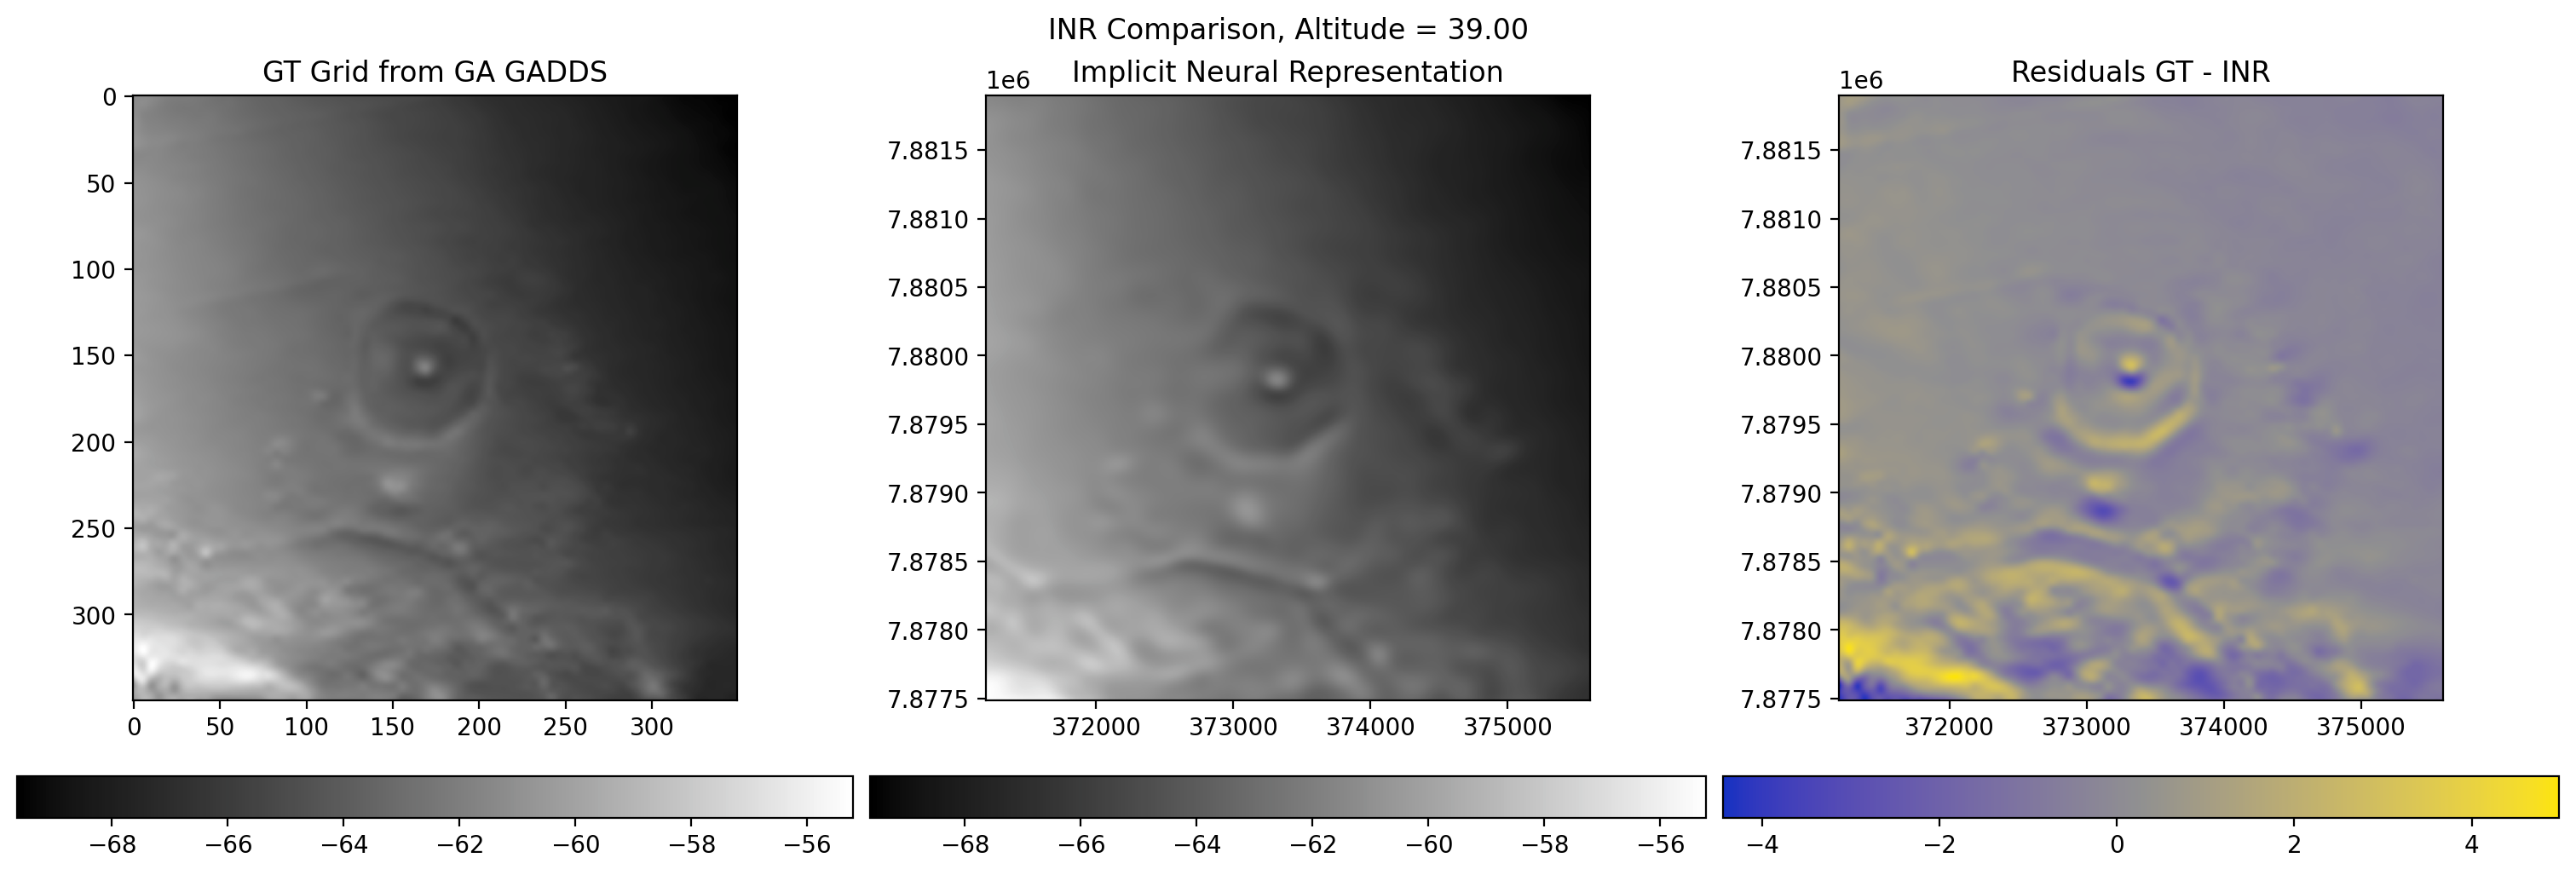

In [9]:
# Set up parameters for querying
gtt = tifffile.imread(gtt_path)
normalise_fn = dataset.normalise
unnormalise_fn = dataset.unnormalise

shape = (gtt.shape[1], gtt.shape[0], 1)
altitude = 39  # dataset.ncd.variables["altitude"][:].mean()
z_mod = normalise_fn(altitude, "up")
altitude = unnormalise_fn(z_mod, "up")

extent = [
    unnormalise_fn(dataset.extent[0], "e"),
    unnormalise_fn(dataset.extent[1], "e"),
    unnormalise_fn(dataset.extent[2], "n"),
    unnormalise_fn(dataset.extent[3], "n"),
]

ax_args = dict(cmap=cc.cm.CET_L1)

u = query_inr_batched(
    inr,
    shape=shape,
    chunksize=1_024_000,
    z_mod=z_mod,
    # x_vec=torch.linspace(dataset.extent[0], dataset.extent[1], steps=shape[0]),
    # y_vec=torch.linspace(dataset.extent[2], dataset.extent[3], steps=shape[1]),
    # z_vec = normalise_fn(torch.linspace(40, 60, steps=shape[2]), "z")
)
u = unnormalise_fn(u, "u")

fig = plt_inr(
    u.squeeze(),
    altitude,
    extent=extent,
    ax_args=ax_args,
    gt_grid=gtt,
    figsize=(15, 5),
    cropping=(50, 400),
    dpi=200,
)


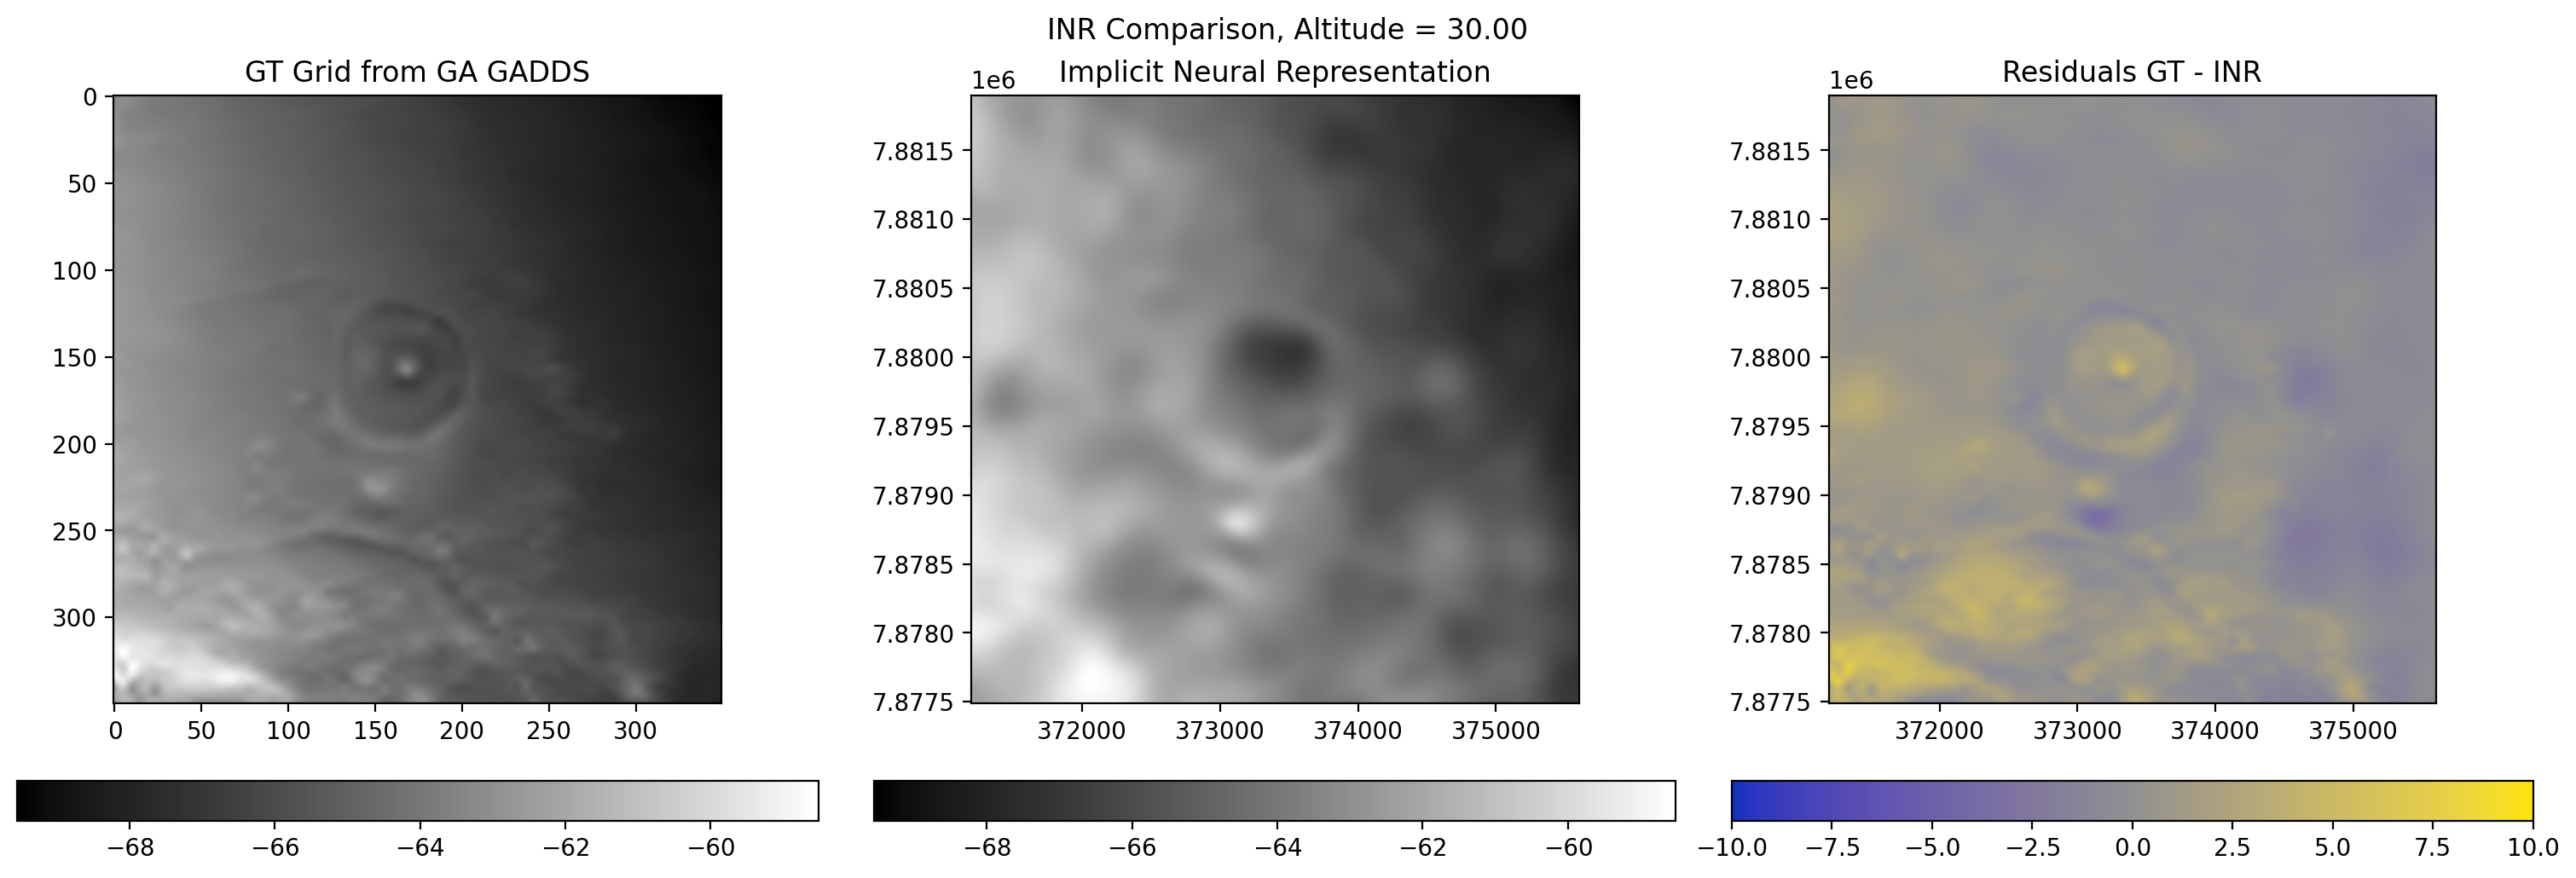

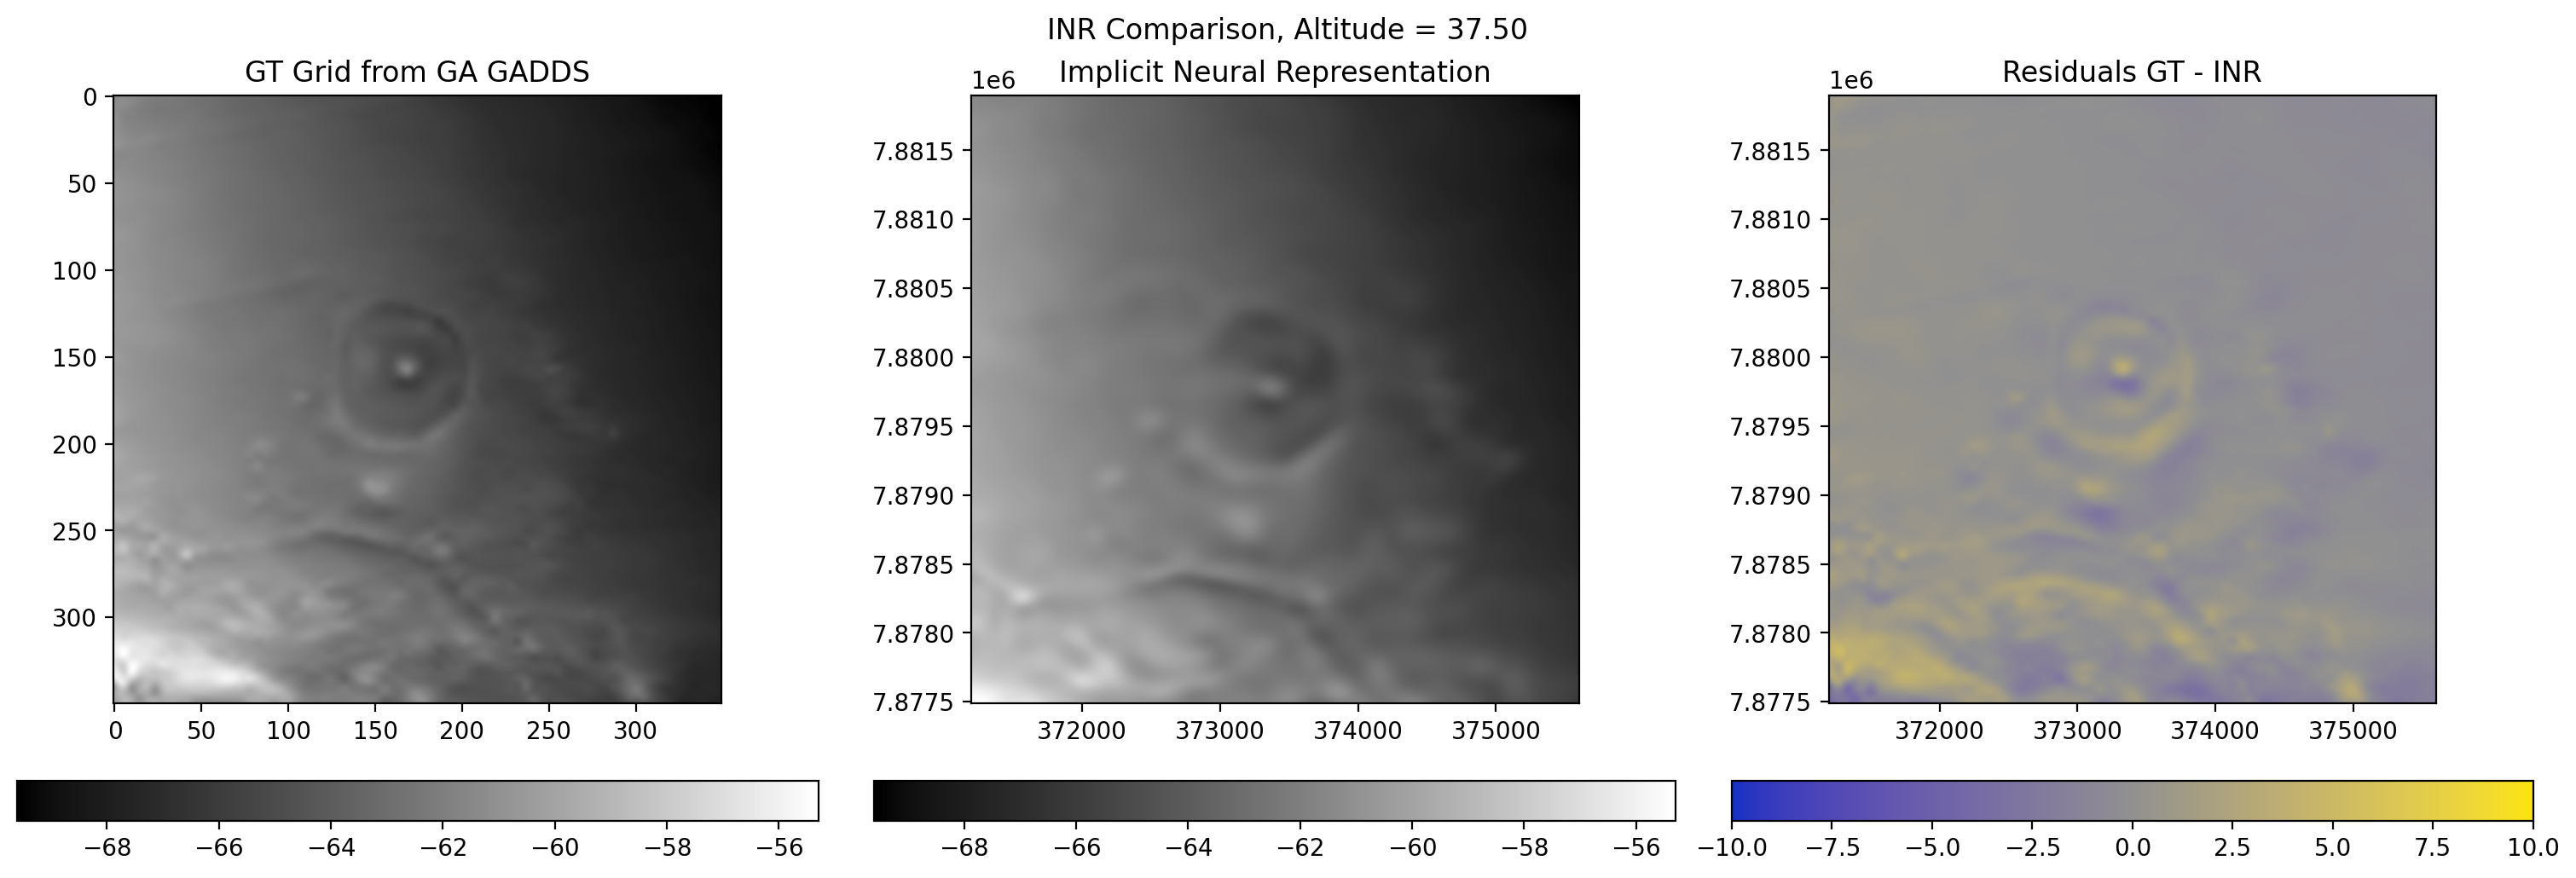

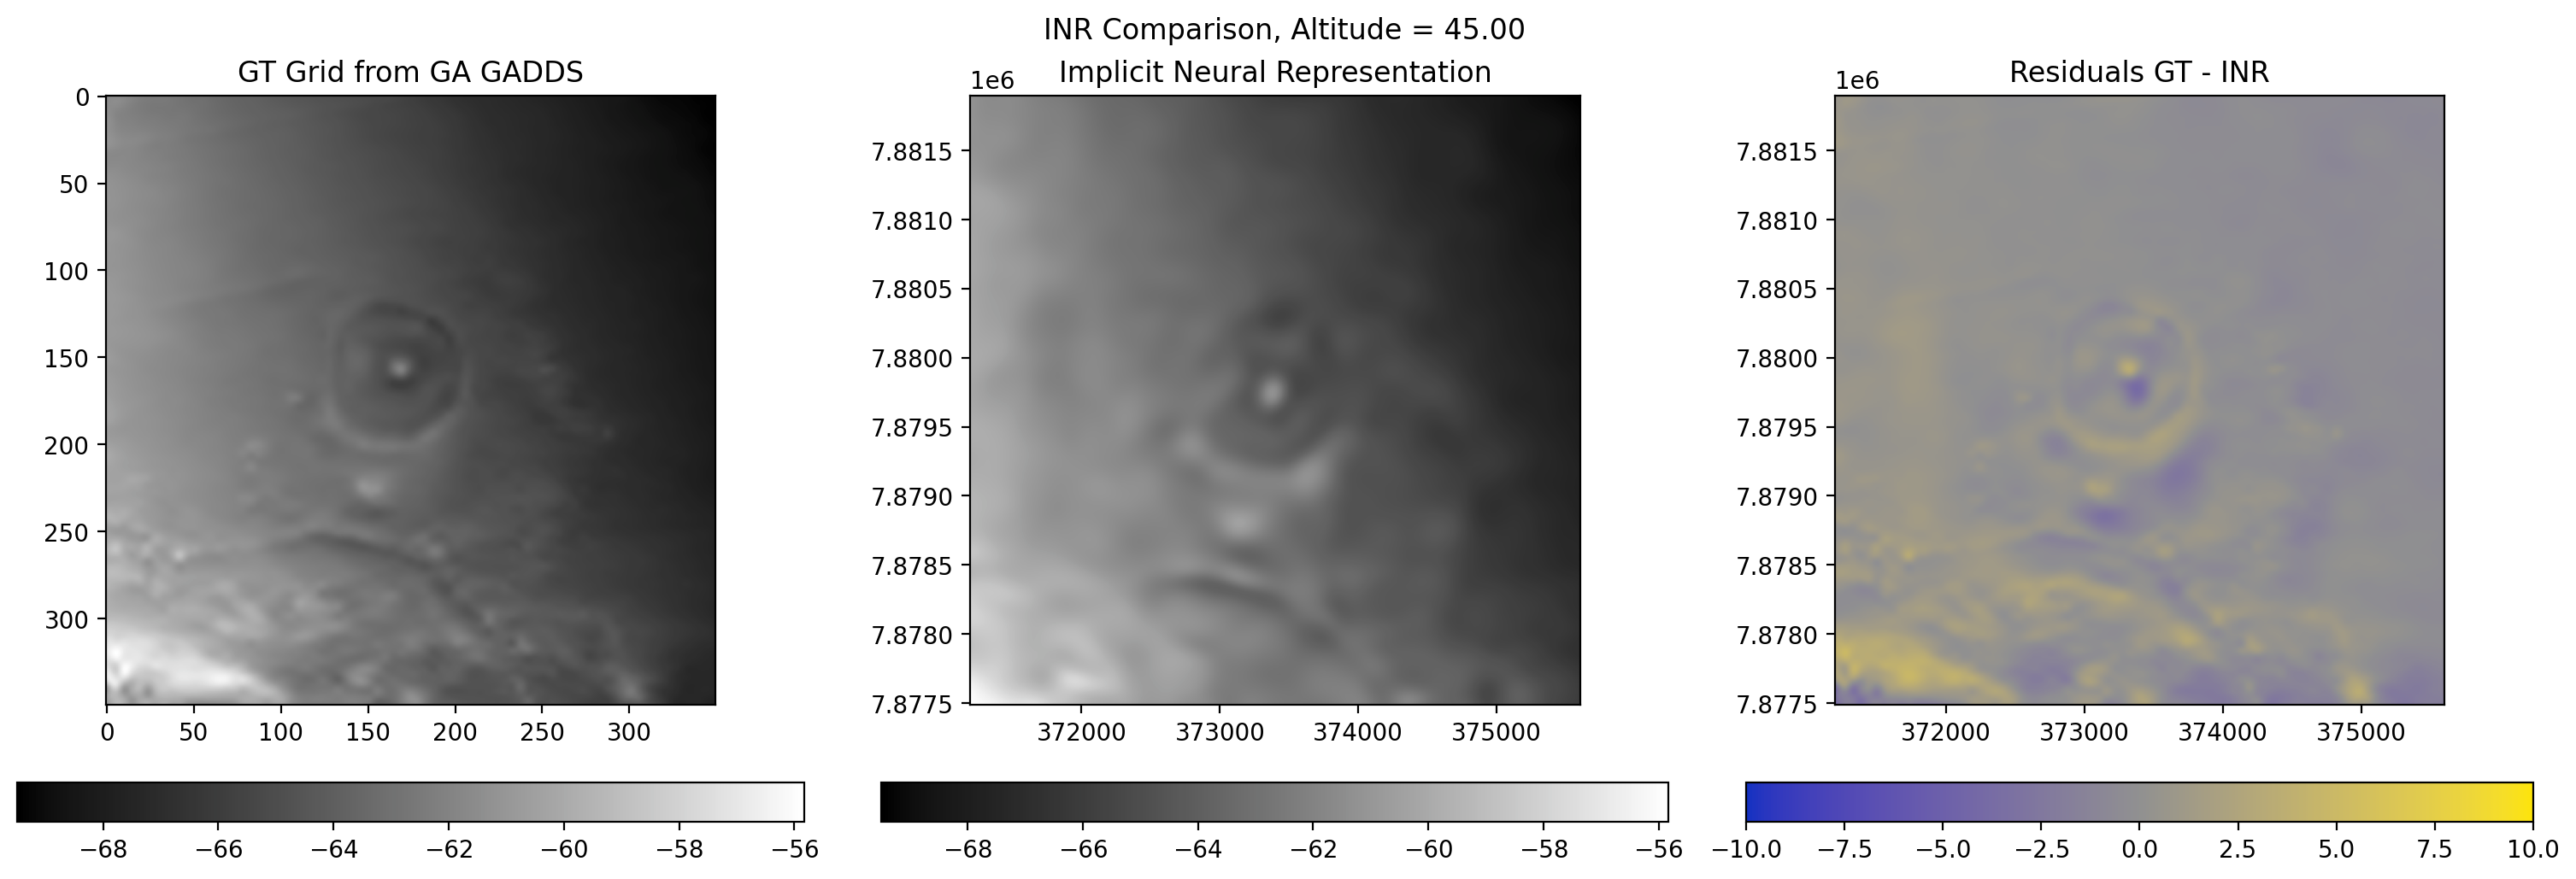

In [10]:
# Batched 3D volume query
shape = (456, 455, 3)  # shape(0,1) needs to match GT shape for comparisons
z_vec = normalise_fn(torch.linspace(30, 45, steps=shape[2]), "up")

u = query_inr_batched(inr, shape=shape, chunksize=256_000, z_vec=z_vec)
u = unnormalise_fn(u, "u")

for i, u in enumerate(u.transpose(2, 0, 1)):  # Iter through zxy slices
    altitude = unnormalise_fn(z_vec[i], "up")
    fig = plt_inr(
        u,
        altitude,
        extent=extent,
        ax_args=ax_args,
        _vmax=10,
        _vmin=-10,
        gt_grid=gtt,
        figsize=(15, 5),
        cropping=(50, 400),
        dpi=200,
    )
    plt.show()


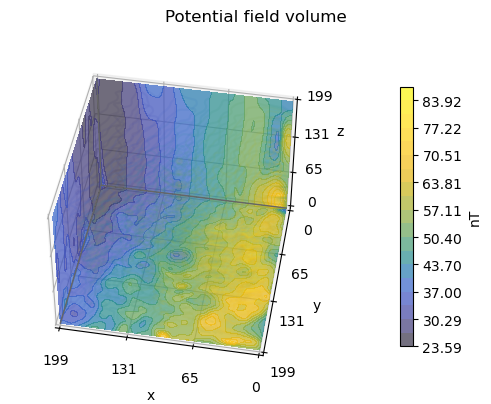

In [11]:
u = query_inr_batched(
    inr,
    shape=(200, 200, 200),
    chunksize=256_000,
    z_vec=normalise_fn(torch.linspace(30, 45, steps=200), "up"),
)
plt_3d(
    unnormalise_fn(u, "up"),
    ori="z",
    levels=20,
    step=21,
    elezv=30,
    azim=100,
    linear_width=30,
    alpha=0.1,
)


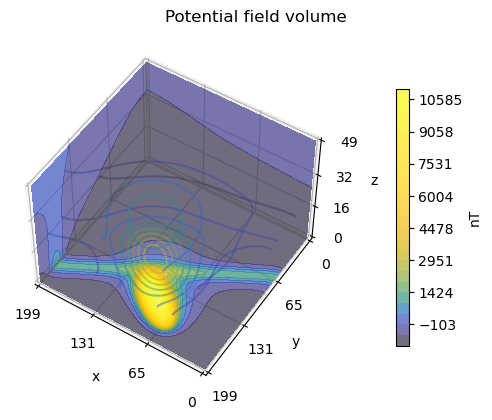

In [12]:
# Noddyverse Synthetic Comparison
plt_3d(
    u=merge_z_slices(Path("/mnt/win_data/luke/data_source/Forward_models_xyz"), idx=1),
    ori="z",
    step=20,
    elev=50,
    azim=123,
    linear_width=1000,
    cmap=cc.cm.CET_L20,
    alpha=0.5,
)


Explicit function: $$u(x,y,z) = \sin(x+y+z) + \cos(x-y-z)$$

Explicit x, y, z partial derivatives:
$$\frac{\partial{u(x,y,z)}}{\partial{x}} = \cos(x+y+z) - \sin(x-y-z)$$ 
$$\frac{\partial{u(x,y,z)}}{\partial{y}} = \cos(x+y+z) + \sin(x-y-z)$$
$$\frac{\partial{u(x,y,z)}}{\partial{z}} = \cos(x+y+z) + \sin(x-y-z)$$

In [13]:
# ## Custom Function sample:
# # TODO make a custom geophysical test grid with just a box.
# def cust_f(d=200, a=1, l=1):
#     x, y, z = np.meshgrid(
#         np.linspace(-l, l, d),
#         np.linspace(-l, l, d),
#         np.linspace(-l, l, d),
#         indexing="xy",
#     )
#     u = a * (np.sin(x + y + z) + np.cos(x - y - z))
#     return (x, y, z, u)


# def cust_df(d=200, a=1, l=1):
#     x, y, z = np.meshgrid(
#         np.linspace(-l, l, d),
#         np.linspace(-l, l, d),
#         np.linspace(-l, l, d),
#         indexing="xy",
#     )
#     dudx = a * (np.cos(x + y + z) - np.sin(x - y - z))
#     dudy = a * (np.sin(x - y - z) + np.cos(x + y + z))
#     dudz = a * (np.sin(x - y - z) + np.cos(x + y + z))

#     return (dudx, dudy, dudz)


In [14]:
# a = 1
# l = 4
# x, y, z, u = cust_f(d=200, a=a, l=l)
# dudx, dudy, dudz = cust_df(d=50, a=a, l=l)
# plt.imshow(u[25])
# # plt_3d(u, ori="z", step=50, elev=33, azim=120, linear_width=1, alpha=1)


In [15]:
# opts = dict(ori="x", step=10, elev=45, azim=135, linear_width=1, cmap=cc.cm.CET_L1)

# fig = plt.figure(figsize=(30, 10), layout="constrained")
# ax = fig.add_subplot(131, projection="3d")
# plt_3d(dudx, **opts, ax=ax, fig=fig)
# ax = fig.add_subplot(132, projection="3d")
# plt_3d(dudy, **opts, ax=ax, fig=fig)
# ax = fig.add_subplot(133, projection="3d")
# plt_3d(dudz, **opts, ax=ax, fig=fig)
# # plt_3d(dudx, **opts, ax=fig.add_subplot(234, projection="3d"))
# # plt_3d(dudy, **opts, ax=fig.add_subplot(235, projection="3d"))
# # plt_3d(dudz, **opts, ax=fig.add_subplot(236, projection="3d"))


So we've established that an Implicit function such as SIREN can learn a grid extent quite well.  
Now we want to calculate the gradients (Jacobian) using the network.  
We do this as a calculation of the gradients between the model inputs (x,y) and the model output (u) which is the TMI at that x,y point.

There are several ways to calculate the Jacobian:  
1. `torch.autograd.grad`
1. `torch.autograd.functional.jacobian(vectorize=True)`
1. `functorch.jacrev`

https://github.com/pytorch/pytorch/issues/23475#issuecomment-946927242

We want the Jacobian: $$J(x,y) = [\frac{\partial{u(x,y)}}{\partial{x}}, \frac{\partial{u(x,y)}}{\partial{y}}]$$

Where $$ u = f(x,y)\,,\, f:R^2 \to R^1$$
This is the special case where _the Jacobian matrix reduces to the row vector $${\displaystyle \nabla ^{\mathrm {T} }f}$$ this row vector of all first-order partial derivatives of f is the transpose of the gradient of f $${\displaystyle \mathbf {J} _{f}=\nabla ^{T}f}. $$_



In [16]:
def gradient(u, xyz, grad_outputs=None):
    if grad_outputs is None:
        grad_outputs = torch.ones_like(u)
    grad = torch.autograd.grad(u, [xyz], grad_outputs=grad_outputs, create_graph=True)[
        0
    ]
    return grad


def divergence(u, xyz):
    div = 0.0
    for i in range(u.shape[-1]):
        div += torch.autograd.grad(
            u[..., i], xyz, torch.ones_like(u[..., i]), create_graph=True
        )[0][..., i : i + 1]
    return div


def laplace(u, xyz):
    return divergence(gradient(u, xyz), xyz)


def s_jacobian(u, xyz):
    """jacobian of u wrt x"""
    meta_batch_size, num_observations = u.shape[:2]
    jac = torch.zeros(meta_batch_size, num_observations, u.shape[-1], xyz.shape[-1]).to(
        u.device
    )  # (meta_batch_size*num_points, 2, 2)
    for i in range(u.shape[-1]):
        # calculate dydx over batches for each feature value of y
        u_flat = u[..., i].view(-1, 1)
        jac[:, :, i, :] = torch.autograd.grad(
            u_flat, xyz, torch.ones_like(u_flat), create_graph=True
        )[0]

    status = 0
    if torch.any(torch.isnan(jac)):
        status = -1

    return jac, status


In [17]:
## Simple method for "Gradient", torch.autograd.grad
## The gradient is a special case of the Jacbian, when the function is scalar
## https://math.stackexchange.com/questions/1519367/difference-between-gradient-and-jacobian

shape = (200, 200, 1)
query_xyz = construct_xyz((200, 200, 1), z_mod=-0.4)
query_xyz.requires_grad_(True)
query_xyz = query_xyz.to(device)

inr.return_coords = True
pred_u, query_xyz = inr(query_xyz)

pred_u = dataset.unnormalise(pred_u, var="u")
u = pred_u.detach().cpu().clone().view(shape).rot90().squeeze().numpy()

grad = torch.autograd.grad(
    outputs=pred_u,
    inputs=[query_xyz],
    grad_outputs=torch.ones_like(pred_u),
    create_graph=True,
    retain_graph=True,
    allow_unused=True,
)
# grad = [grad[0]]
# print(f"{grad[0].shape = }")


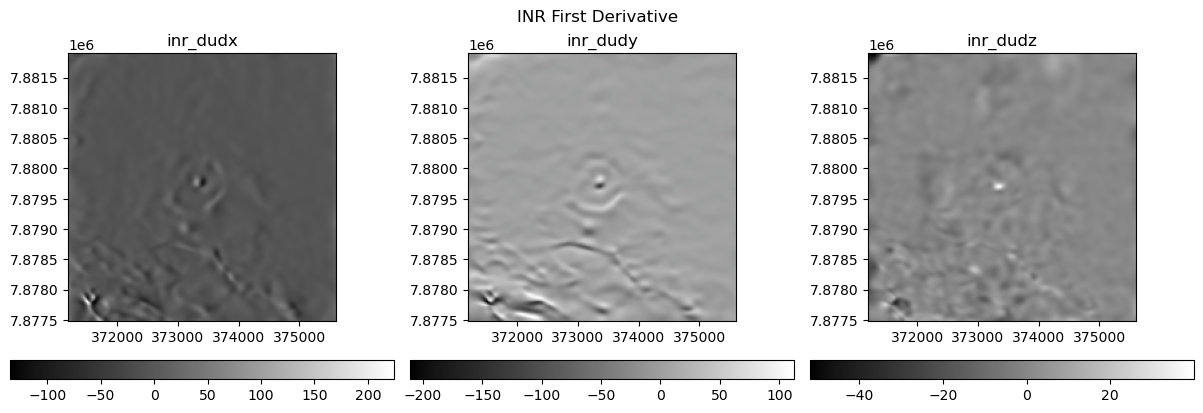

In [18]:
# First Derivative?
inr_dudx, inr_dudy, inr_dudz = grad[0].detach().cpu().squeeze().permute(1, 0)
inr_dudx = inr_dudx.view(shape[:2]).rot90().numpy()
inr_dudy = -inr_dudy.view(shape[:2]).rot90().numpy()  # NOTE Negative sign
inr_dudz = inr_dudz.view(shape[:2]).rot90().numpy()

ax_args = dict(cmap=cc.cm.CET_L1, extent=extent)

plt_kwargs(
    "INR First Derivative",
    ax_args,
    inr_dudx=inr_dudx,
    inr_dudy=inr_dudy,
    inr_dudz=inr_dudz,
)


/home/luke/mambaforge/envs/phd/lib/python3.11/site-packages/xrft/xrft.py:573: FutureWarning: Default ifft's behaviour (lag=None) changed! Default value of lag was zero (centered output coordinates) and is now set to transformed coordinate's attribute: 'direct_lag'.
  warnings.warn(msg, FutureWarning)


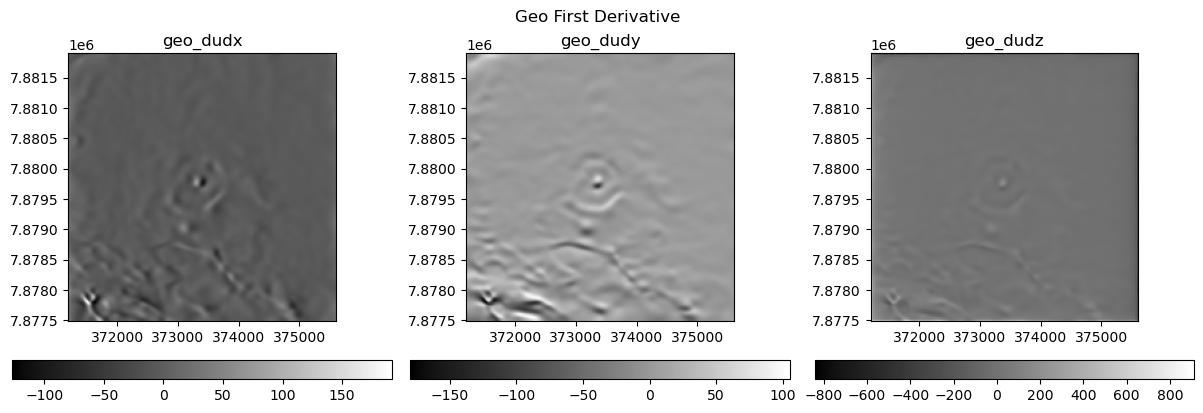

In [19]:
geo_u = xr.DataArray(
    u,
    coords=({"northing": np.linspace(-1, 1, 200), "easting": np.linspace(-1, 1, 200)}),
)
geo_dudx = harmonica.derivative_easting(geo_u)
geo_dudy = harmonica.derivative_northing(geo_u)
geo_dudz = harmonica.derivative_upward(geo_u)

plt_kwargs(
    "Geo First Derivative",
    ax_args,
    shape=(1, 3),
    geo_dudx=geo_dudx,
    geo_dudy=geo_dudy,
    geo_dudz=geo_dudz,
)


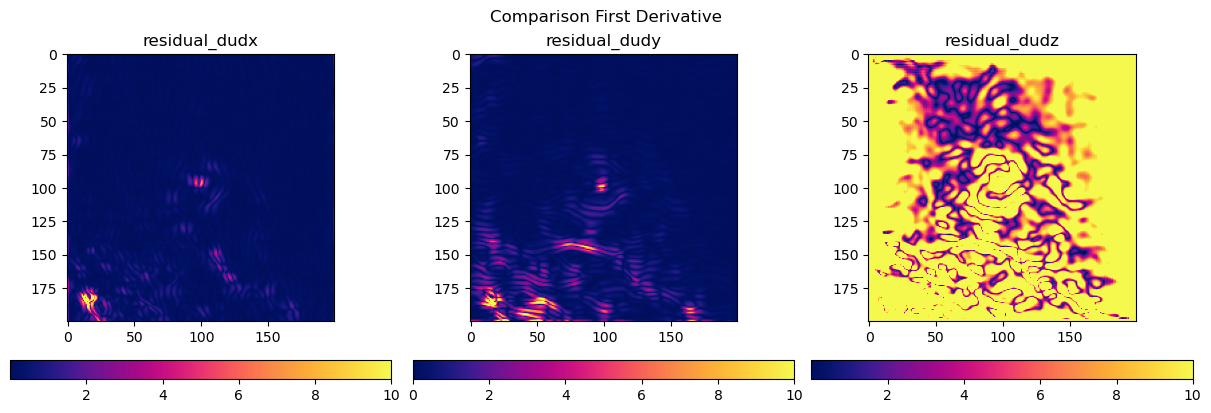

In [20]:
plt_kwargs(
    r"Comparison First Derivative",
    {"cmap": cc.cm.CET_L8, **{"vmax": 10}},
    shape=(1, 3),
    residual_dudx=np.sqrt((geo_dudx - inr_dudx)**2),
    residual_dudy=np.sqrt((geo_dudy - inr_dudy)**2),
    residual_dudz=np.sqrt((geo_dudz - inr_dudz)**2),
)


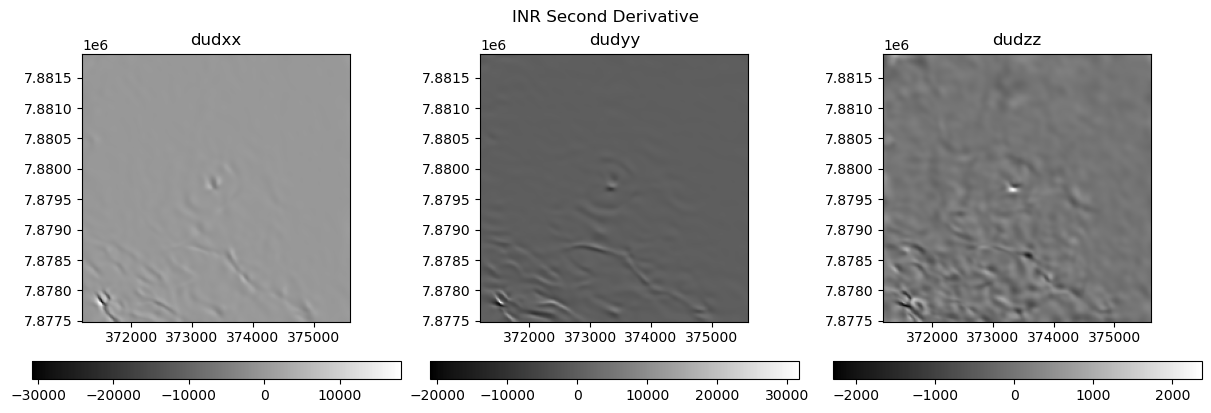

In [21]:
# Second Derivative?
grad2 = torch.autograd.grad(
    outputs=[grad[0]],
    inputs=[query_xyz],
    grad_outputs=torch.ones_like(grad[0]),
    create_graph=True,
    retain_graph=True,
    allow_unused=True,
)
dxx, dyy, dzz = grad2[0].detach().cpu().squeeze().permute(1, 0)

plt_kwargs(
    "INR Second Derivative",
    ax_args,
    dudxx=dxx.view(shape[:2]).rot90().numpy(),
    dudyy=-dyy.view(shape[:2]).rot90().numpy(),
    dudzz=dzz.view(shape[:2]).rot90().numpy(),
)


/home/luke/mambaforge/envs/phd/lib/python3.11/site-packages/xrft/xrft.py:573: FutureWarning: Default ifft's behaviour (lag=None) changed! Default value of lag was zero (centered output coordinates) and is now set to transformed coordinate's attribute: 'direct_lag'.
  warnings.warn(msg, FutureWarning)


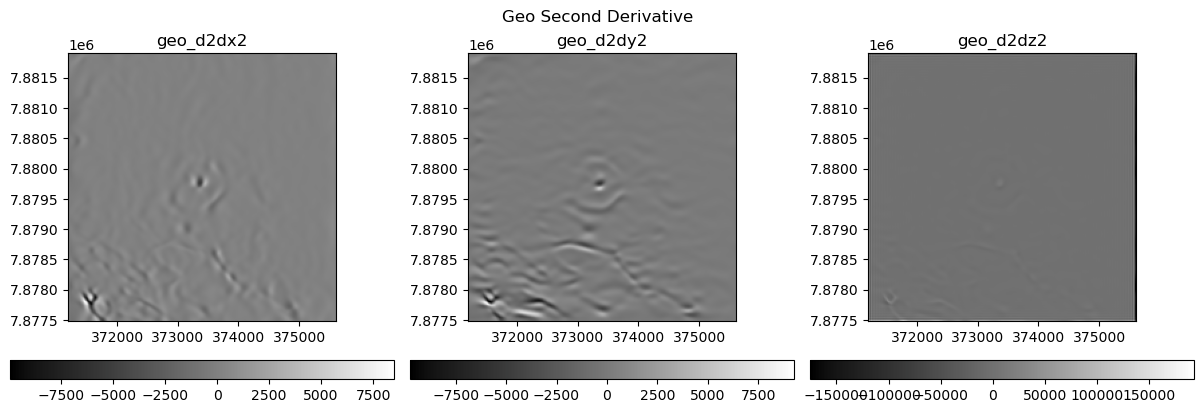

In [22]:
u = xr.DataArray(
    u,
    coords=({"northing": np.linspace(-1, 1, 200), "easting": np.linspace(-1, 1, 200)}),
)
geo_d2dx2 = harmonica.derivative_easting(u, order=2)
geo_d2dy2 = harmonica.derivative_northing(u, order=2)
geo_d2dz2 = harmonica.derivative_upward(u, order=2)

plt_kwargs(
    "Geo Second Derivative",
    ax_args,
    geo_d2dx2=geo_d2dx2,
    geo_d2dy2=geo_d2dy2,
    geo_d2dz2=geo_d2dz2,
)


## TODO

In [23]:
xmin = dudx.min()
xmax = dudx.max()
ymin = dudy.min()
ymax = dudy.max()

plt.figure(constrained_layout=True, figsize=(10, 10))
plt.subplot(221)
plt.title("Analytical dudx")
plt_cntr(dx)
plt.subplot(222)
plt.title("Implicit dudx")
plt.imshow(dudx, origin="lower", cmap=cc.cm.CET_L1, vmin=xmin, vmax=xmax)
plt.colorbar()
plt.subplot(223)
plt.title("Analytical dudy")
plt_cntr(dudy)
plt.subplot(224)
plt.title("Implicit dudy")
plt.imshow(dy, origin="lower", cmap=cc.cm.CET_L1, vmin=ymin, vmax=ymax)
plt.colorbar()


NameError: name 'dudx' is not defined

In [ ]:
def gradients(pred_u, xy_coord):
    """Compute the xx and yy gradients of the Implicit Function
    When trained, inputs of (x,y) coords to a Siren model (F) return u.
    Generally, this is u = F(x,y)
    """
    return (
        torch.autograd.grad(
            outputs=pred_u,
            inputs=[xy_coord],
            grad_outputs=torch.ones_like(pred_u),
            create_graph=True,
            retain_graph=True,
            allow_unused=True,
        )[0]
        .detach()
        .reshape(dset.s, dset.s, 2)
        .permute(2, 0, 1)
        .cpu()
        # .numpy()
    )


# Below references are per Blakely, R. J. 1996
# _Potential Theory in Gravity and Magnetic Applications_
# Cambridge University Press


def horizontal_gradient(dudy, dudx):
    """Horizontal Gradient, eqn 12.49"""
    # return torch.sqrt(dudx ** 2 + dudy ** 2)
    return torch.dstack((dudy, dudx)).norm(dim=-1, p="fro")


def upward_continuation():
    """Upward Continuation, eqn 12.4
    It would be interesting to include u in the coords, and predict this
    """
    # (dz / 2 * pi) * double integral (output_xyz0) / ((x-x')^2 + (y-y')^2 + (dz**2))**(3/2) dxdy

    return NotImplementedError


def downward_continuation(du):
    """Downward Continuation, eqn 12.5
    args:
        - du: vertical distance to downward continue



    """

    return NotImplementedError


def vertical_derivative(order=1):
    """Vertical Derivative, eqn 12.17
    Args:
        order (int): Order of derivative, e.g. 2 for 2VD

    """
    return NotImplementedError


In [ ]:
pred_u, xy_coord = img_siren(model_input)
dudy, dudx = gradients(pred_u, model_input)
horiz_g = horizontal_gradient(dudy, dudx)


In [ ]:
plt.imshow(horiz_g, cmap=cc.cm.CET_L1, origin="lower")
plt.title("Horizontal Gradient")


In [ ]:
crop = dset.original_shape
# w,e,s,n = (0, crop[-2], 0, crop[-1])
w, e, s, n = zoom


In [ ]:
import matplotlib.colors as colors

fig, axs = plt.subplots(3, 2, layout="constrained", figsize=(10, 12))
plt.suptitle(f"Horizontal Derivatives - {sample.stem}")
plt_opts = dict(origin="upper", cmap=cc.cm.CET_L1)
[[axg, axp], [axx, axy], [axh, axoff]] = axs

axg.set_title(r"Original TMI Grid")
caxi = axg.imshow(
    dset.original_grid.squeeze()[s:n, w:e], cmap=cc.cm.CET_L1, origin="lower"
)
plt.colorbar(mappable=caxi, ax=axg, label=r"nT", location="bottom")

axp.set_title(r"Learnt TMI Grid")
caxp = axp.imshow(
    pred_u.detach().cpu().view(dset.s, dset.s).squeeze()[s:n, w:e], cmap=cc.cm.CET_L1
)
plt.colorbar(mappable=caxp, ax=axp, label=r"nT", location="bottom")

axh.set_title(r"Horizontal gradient")
caxh = axh.imshow(horiz_g[s:n, w:e], cmap=cc.cm.CET_L1, vmin=0, vmax=10)
plt.colorbar(mappable=caxh, ax=axh, label=r"nT/cell", location="bottom")

axx.set_title(r"$\delta$u$\delta$x")
caxx = axx.imshow(dudx[s:n, w:e], **plt_opts)  # , vmin=-8, vmax=8)
plt.colorbar(mappable=caxx, ax=axx, label=r"nT/cell", location="bottom")

axy.set_title(r"$\delta$u$\delta$y")
caxy = axy.imshow(dudy[s:n, w:e], **plt_opts)  # , vmin=-8, vmax=8)
plt.colorbar(mappable=caxy, ax=axy, label=r"nT/cell", location="bottom")

# norm = colors.LogNorm(vmin=0.1, vmax=60)
axoff.axis("off")

for ax in axs.ravel():
    ax.set_xlabel("x")
    ax.set_ylabel("y")


In [ ]:
# ## SPARE BITS###


# # from functorch import vmap, vjp, jacrev

# # vmap(jacrev(img_siren))(model_input)
# ###

# j = (dudx, dudy) = torch.autograd.functional.jacobian(lambda t: img_siren(t), model_input)#, vectorize=True)
# ###

# ## Sitzmann et al. method (non vectorised)
# meta_batch_size = pred_u.shape[0]  # only 1 tile
# num_observations = pred_u.shape[1]  # Num XYZ points,
# out_vecs = pred_u.shape[-1]  # num output channels, 1
# in_ch = xy_coord.shape[-1]  # num input channels, 2

# jac = torch.zeros(meta_batch_size, num_observations, out_vecs, in_ch).to(
#     pred_u.device
# )  # (meta_batch_size*num_points, 2, 2)
# for vec in range(out_vecs):
#     # calculate dydx over batches for each feature value of y
#     y_flat = pred_u[..., vec].view(-1, 1)
#     jac[:, :, vec, :] = torch.autograd.grad(
#         y_flat, xy_coord, torch.ones_like(y_flat), create_graph=True
#     )[0]

# ###

# jac2 = jac.squeeze().reshape(200,200,2).permute(2,0,1)[1]
# plt.imshow(jac2.detach().cpu().numpy())
# plt.colorbar()
# ###


# from functorch import vmap, vjp, jacrev

# def f(x):
#     return img_siren(x)

# j = jacrev(f)(model_input.squeeze())

# print(model_input.squeeze().shape)
# print(f"{j[0].shape=}")
# print(f"{j[1].shape=}")

# ###

# ## As of pytorch 1.13, we can now use functorch operations
# ## https://pytorch.org/functorch/stable/notebooks/jacobians_hessians.html

# # from functorch import vmap, vjp, jacfwd, jacrev
# # torch.manual_seed(0)

# # img_siren

# # m = model_input.clone().requires_grad_()

# # cotangents = torch.eye(m.shape[1])
# # _, vjp_fn = vjp((img_siren), m)
# # vmap(vjp_fn)(cotangents)

# # # ft_jacobian = jacrev(img_siren, argnums=(0,))(m)

# # # ft_jacobian = vmap(jacrev(img_siren, argnums = 0), in_dims=(None, 0, None))
# # # btach_jac = ft_jacobian( )

# # model_output, coords = img_siren(model_input)
# # print(f"{model_input.shape=}")
# # print(f"{img_siren(model_input)[0].shape=}")
# # print(f"{img_siren(model_input)[1].shape=}")

# # j = torch.autograd.functional.jacobian(lambda x: img_siren(x)[0], model_input, vectorize=True)
# # j2 = torch.diagonal(j, offset=0, dim1=0, dim2=2)
# # j3 = j2.permute(2,0,1)

# # j2.shape
# # j.squeeze()[1].reshape(s, s, 2).shape
